# 图像分辨率 × Think cap × 蒸馏步数:延迟三维 sweep(最终实验)

在 `think_cap_benchmark` 已确立的两条线性定律基础上,加入第三个自变量——**图像分辨率 R**:

- 已知:`t_think ≈ 0.055·T`(与 N 无关);`t_image ≈ 0.53·N` @1024(与 cap 无关)
- 图像 token 数 = `(R / 16)²`(VAE 8× 下采样 × latent_patch 2×);R=1024 → 4096 token
- **R 上限就是 1024**(`max_latent_size = 64`),只能向下扫;边长须为 16 的倍数

## 假设

| # | 假设 | 检验方式 |
|---|------|---------|
| H1 | `t_image(N, R) = s(R)·N`,对 N 线性在所有 R 下成立 | §5 分组线性拟合,看截距≈0、R² |
| H2 | `s(R) ≈ a + b·tok(R)`(+ 可能的二次项 c·tok²,来自 attention) | §6 线性 vs 二次拟合对比 |
| H3 | t2i 无图像输入,`t_think` 应与 R **完全无关**(计时自检) | §8 Kruskal-Wallis,预期不显著 |

推论:`ratio ≈ 0.055·T / (s(R)·N)`,平衡点 `T* ≈ s(R)·N / 0.055` —— 分辨率越低,think 越容易成为瓶颈。

## 网格

R ∈ {1024, 768, 512, 256} × N ∈ {50, 10, 5} × cap ∈ {1000, 256, 128, 64, 32}
= 60 conditions × 16 prompts × 2 repeats = **1920 trials**(4 workers × 2 GPU,预计 ~2h)

> 执行侧复用已验证的多卡架构(`experiments/run_res_sweep_mp.py`,
> 与 `run_cap_sweep_mp.py` 同构:subprocess + CUDA_VISIBLE_DEVICES + 手动均衡 device_map)。
> 本 notebook 只负责启动 sweep 和分析结果,内核本身不加载模型。


## 1. 环境 / import

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, kruskal

# 允许从 repo root 或 experiments/ 目录启动
if os.path.basename(os.getcwd()) == "experiments":
    os.chdir("..")

OUTPUT_DIR = "experiments/think_res_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LATENT_DOWNSAMPLE = 16
IMAGE_SIDE_LIST = [1024, 768, 512, 256]
NUM_TIMESTEPS_LIST = [50, 10, 5]
MAX_THINK_TOKEN_LIST = [1000, 256, 128, 64, 32]

print("cwd:", os.getcwd())


cwd: /home/wuwenxuan03/bagel


## 2. 多卡并行 sweep(launcher)

启动 `run_res_sweep_mp.py`(4 workers × 2 GPU)。**如果 `think_res_outputs/trials.csv` 已存在,
这个 cell 会跳过运行直接进入 §3**;想强制重跑就把 `FORCE_RERUN = True`。

In [2]:
import subprocess, sys

FORCE_RERUN = True
merged_path = os.path.join(OUTPUT_DIR, "trials.csv")

if os.path.exists(merged_path) and not FORCE_RERUN:
    print(f"{merged_path} 已存在,跳过 sweep(FORCE_RERUN=True 可强制重跑)")
else:
    print("启动多卡并行 sweep (4 workers × 2 GPU)...")
    result = subprocess.run(
        [sys.executable, "experiments/run_res_sweep_mp.py",
         "--gpus", "0,1,2,3,4,5,6,7",
         "--gpus-per-worker", "2"],
        cwd=os.getcwd(),
        capture_output=False,  # 实时输出进度
    )
    if result.returncode == 0:
        print("\n多卡 sweep 完成!")
    else:
        print(f"\n多卡 sweep 失败 (exit code {result.returncode}),检查终端输出")


启动多卡并行 sweep (4 workers × 2 GPU)...
Total trials: 1920 (4R × 3N × 5cap × 16 prompts × 2 repeats)
Workers: 4 (each using 2 GPU(s))
  Worker 0: GPU(s) [0, 1]
  Worker 1: GPU(s) [2, 3]
  Worker 2: GPU(s) [4, 5]
  Worker 3: GPU(s) [6, 7]
Trials per worker: ~480
Estimated time: ~2.0h

[Main] Spawned worker 0 (PID 196621) on GPU(s) 0,1
[Main] Spawned worker 1 (PID 196622) on GPU(s) 2,3
[Main] Spawned worker 2 (PID 196623) on GPU(s) 4,5
[Main] Spawned worker 3 (PID 196624) on GPU(s) 6,7
[Worker 2] Visible GPUs: 2 (NVIDIA GeForce RTX 4090)
[Worker 2] Trials: 480
[Worker 2] Loading with accelerate device_map (2 GPUs)...
[Worker 1] Visible GPUs: 2 (NVIDIA GeForce RTX 4090)
[Worker 1] Trials: 480
[Worker 1] Loading with accelerate device_map (2 GPUs)...
[Worker 3] Visible GPUs: 2 (NVIDIA GeForce RTX 4090)
[Worker 3] Trials: 480
[Worker 3] Loading with accelerate device_map (2 GPUs)...
[Worker 0] Visible GPUs: 2 (NVIDIA GeForce RTX 4090)
[Worker 0] Trials: 480
[Worker 0] Loading with accelerate de

The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.
The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.
The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.
The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.
We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Ple

[Worker 3] Warm-up @ 1024x1024...


We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Please make sure to update your driver to the latest version which resolves this.
We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Please make sure to update your driver to the latest version which resolves this.
We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Please make sure to update your driver to the latest version which resolves this.


[Worker 1] Warm-up @ 1024x1024...
[Worker 0] Warm-up @ 1024x1024...
[Worker 2] Warm-up @ 1024x1024...


...

[Worker 1] [480/480] ok=480/480, elapsed=6091s, ETA=0s
[Worker 1] DONE: 480/480 ok in 6091s → /home/wuwenxuan03/bagel/experiments/think_res_outputs/worker_1.csv
[Main] Worker 1 DONE
[Main] Worker 2 DONE


100%|██████████| 49/49 [00:05<00:00,  8.49it/s]


[Worker 3] [470/480] ok=470/470, elapsed=6113s, ETA=130s


100%|██████████| 9/9 [00:01<00:00,  8.46it/s]


[Worker 3] [480/480] ok=480/480, elapsed=6209s, ETA=0s
[Worker 3] DONE: 480/480 ok in 6209s → /home/wuwenxuan03/bagel/experiments/think_res_outputs/worker_3.csv
[Main] Worker 3 DONE

Merged 1920 rows (1920 ok) → /home/wuwenxuan03/bagel/experiments/think_res_outputs/trials.csv

多卡 sweep 完成!


## 3. 加载结果 + 派生指标

In [3]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "trials.csv"))
print(f"Loaded {len(df)} rows | OK: {df['ok'].sum()} | Failed: {(~df['ok']).sum()}")

ok = df[df["ok"]].copy()
ok["ratio_think_image"] = ok["t_think"] / ok["t_image"]
ok["fraction_think"] = ok["t_think"] / (ok["t_think"] + ok["t_image"])
# image_token_count worker 已记录;兜底重算一次保证列存在
if "image_token_count" not in ok.columns:
    ok["image_token_count"] = (ok["image_side"] // LATENT_DOWNSAMPLE) ** 2

print("\n每个 (R, N, cap) 组合的试次数:")
print(ok.groupby(["image_side", "num_timesteps", "max_think_token_n"]).size().describe())


Loaded 1920 rows | OK: 1920 | Failed: 0

每个 (R, N, cap) 组合的试次数:
count    60.0
mean     32.0
std       0.0
min      32.0
25%      32.0
50%      32.0
75%      32.0
max      32.0
dtype: float64


## 4. 聚合表(60 行:R × N × cap)

In [4]:
agg = (
    ok.groupby(["image_side", "num_timesteps", "max_think_token_n"])
    .agg(
        t_think_mean=("t_think", "mean"), t_think_std=("t_think", "std"),
        t_image_mean=("t_image", "mean"), t_image_std=("t_image", "std"),
        ratio_mean=("ratio_think_image", "mean"),
        fraction_think_mean=("fraction_think", "mean"),
        think_token_count_mean=("think_token_count", "mean"),
        image_token_count=("image_token_count", "first"),
        hit_cap_rate=("hit_cap", "mean"),
        think_closed_rate=("think_closed", "mean"),
        n=("t_think", "count"),
    )
    .reset_index()
    .sort_values(["image_side", "num_timesteps", "max_think_token_n"],
                 ascending=[False, False, False])
)
agg.to_csv(os.path.join(OUTPUT_DIR, "aggregated.csv"), index=False)
agg


,image_side,num_timesteps,max_think_token_n,t_think_mean,t_think_std,t_image_mean,t_image_std,ratio_mean,fraction_think_mean,think_token_count_mean,image_token_count,hit_cap_rate,think_closed_rate,n
59,1024,50,1000,9.024420,0.787030,26.553009,0.291698,0.339918,0.253317,162.25,4096,0.0,1.0,32
58,1024,50,256,9.004571,0.832159,26.561075,0.344539,0.339187,0.252838,162.25,4096,0.0,1.0,32
57,1024,50,128,7.085067,0.069498,26.498459,0.352068,0.267438,0.210993,127.00,4096,1.0,0.0,32
56,1024,50,64,3.526898,0.028717,26.425911,0.314436,0.133489,0.117765,63.00,4096,1.0,0.0,32
55,1024,50,32,1.759688,0.020515,26.525472,0.322925,0.066354,0.062224,31.00,4096,1.0,0.0,32
54,1024,10,1000,9.006271,0.792096,5.150256,0.115054,1.750188,0.635057,162.25,4096,0.0,1.0,32
53,1024,10,256,9.027552,0.811556,5.123125,0.070667,1.762962,0.636757,162.25,4096,0.0,1.0,32
52,1024,10,128,7.048253,0.066534,5.109207,0.076723,1.379878,0.579756,127.00,4096,1.0,0.0,32
51,1024,10,64,3.519064,0.024813,5.132264,0.092118,0.685909,0.406807,63.00,4096,1.0,0.0,32
50,1024,10,32,1.758638,0.020900,5.129023,0.081619,0.342999,0.255369,31.00,4096,1.0,0.0,32


## 5. H1:`t_image = s(R)·N` —— 分组线性拟合

对每个 R,用 trial 级数据拟合 `t_image ~ N`。预期:截距 ≈ 0、R² 接近 1,
且斜率与 cap 无关(cap 只影响 think 段)。

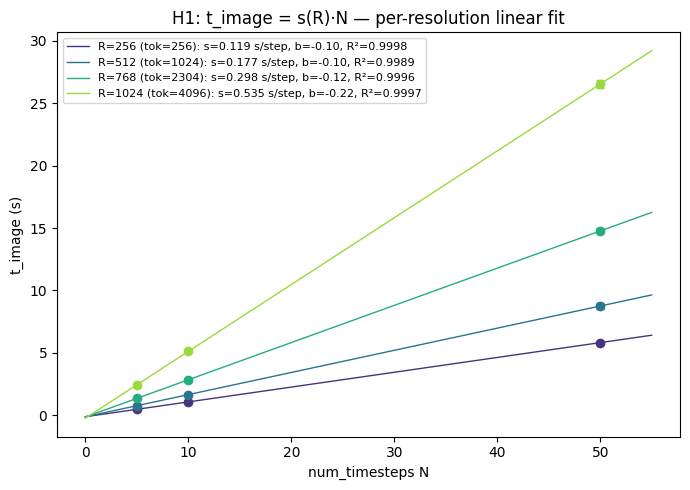

,image_side,image_tokens,s_per_step,intercept,r2,n
3,1024,4096,0.534627,-0.218476,0.999667,480
2,768,2304,0.297637,-0.120104,0.999586,480
1,512,1024,0.177247,-0.104043,0.998873,480
0,256,256,0.118567,-0.100102,0.999831,480


In [5]:
fit_rows = []
fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(IMAGE_SIDE_LIST)))

for color, side in zip(colors, sorted(IMAGE_SIDE_LIST)):
    sub = ok[ok["image_side"] == side]
    x, y = sub["num_timesteps"].values, sub["t_image"].values
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = ((y - y_pred) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    tok = (side // LATENT_DOWNSAMPLE) ** 2
    fit_rows.append(dict(image_side=side, image_tokens=tok,
                         s_per_step=slope, intercept=intercept, r2=r2, n=len(sub)))

    means = sub.groupby("num_timesteps")["t_image"].agg(["mean", "std"]).reset_index()
    ax.errorbar(means["num_timesteps"], means["mean"], yerr=means["std"],
                marker="o", linestyle="none", color=color, capsize=3)
    xs = np.linspace(0, 55, 10)
    ax.plot(xs, slope * xs + intercept, color=color, linewidth=1,
            label=f"R={side} (tok={tok}): s={slope:.3f} s/step, b={intercept:.2f}, R²={r2:.4f}")

ax.set_xlabel("num_timesteps N"); ax.set_ylabel("t_image (s)")
ax.set_title("H1: t_image = s(R)·N — per-resolution linear fit")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "t_image_vs_N_per_R.png"), dpi=150)
plt.show()

fit_df = pd.DataFrame(fit_rows).sort_values("image_side", ascending=False)
fit_df


## 6. H2(核心图):每步成本 `s(R)` vs 图像 token 数

用 §5 得到的 4 个斜率拟合 `s = a + b·tok`(线性)与 `s = a + b·tok + c·tok²`(二次)。
二次项显著 → attention 的平方复杂度可见;截距 a → 每步固定开销
(它解释了低分辨率为什么"不成比例地贵")。注:只有 4 个点,二次拟合自由度=1,结论定性看待。

线性:  s = 0.0727 + 1.090e-04·tok            RSS=1.298e-03
二次:  s = 0.1038 + 5.829e-05·tok + 1.143e-08·tok²  RSS=5.348e-06
外推检验: 线性模型下 s(tok→0) = 0.0727 s/step (每步固定开销)


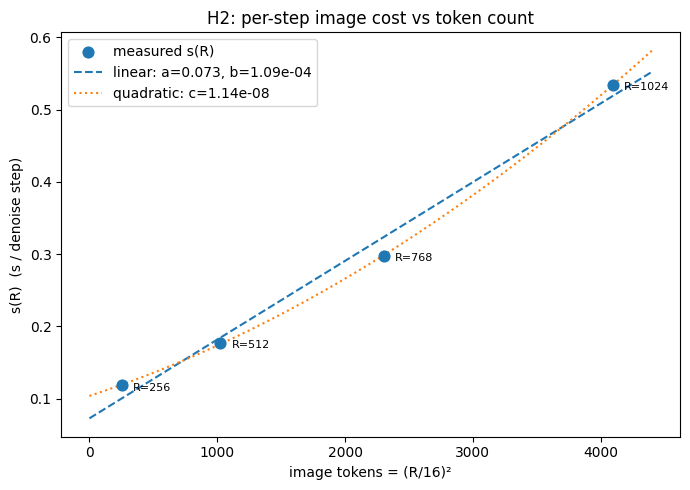

In [6]:
toks = fit_df["image_tokens"].values.astype(float)
s_vals = fit_df["s_per_step"].values

lin = np.polyfit(toks, s_vals, 1)        # [b, a]
quad = np.polyfit(toks, s_vals, 2)       # [c, b, a]
lin_resid = s_vals - np.polyval(lin, toks)
quad_resid = s_vals - np.polyval(quad, toks)

print(f"线性:  s = {lin[1]:.4f} + {lin[0]:.3e}·tok            RSS={np.sum(lin_resid**2):.3e}")
print(f"二次:  s = {quad[2]:.4f} + {quad[1]:.3e}·tok + {quad[0]:.3e}·tok²  RSS={np.sum(quad_resid**2):.3e}")
print(f"外推检验: 线性模型下 s(tok→0) = {lin[1]:.4f} s/step (每步固定开销)")

fig, ax = plt.subplots(figsize=(7, 5))
xs = np.linspace(0, 4400, 200)
ax.scatter(toks, s_vals, s=60, zorder=3, label="measured s(R)")
for t, s, side in zip(toks, s_vals, fit_df["image_side"]):
    ax.annotate(f"R={side}", (t, s), textcoords="offset points", xytext=(8, -4), fontsize=8)
ax.plot(xs, np.polyval(lin, xs), "--", label=f"linear: a={lin[1]:.3f}, b={lin[0]:.2e}")
ax.plot(xs, np.polyval(quad, xs), ":", label=f"quadratic: c={quad[0]:.2e}")
ax.set_xlabel("image tokens = (R/16)²"); ax.set_ylabel("s(R)  (s / denoise step)")
ax.set_title("H2: per-step image cost vs token count")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "s_vs_tokens.png"), dpi=150)
plt.show()


## 7. ratio / fraction_think 全景

左:每个 R 一个面板,ratio vs cap(log-log,虚线 = parity);右:fraction_think 热力图按 R 分面。
预期:R 越小面板整体越"红"(think 占比越高),平衡点 `T* ≈ s(R)·N / 0.055` 左移。

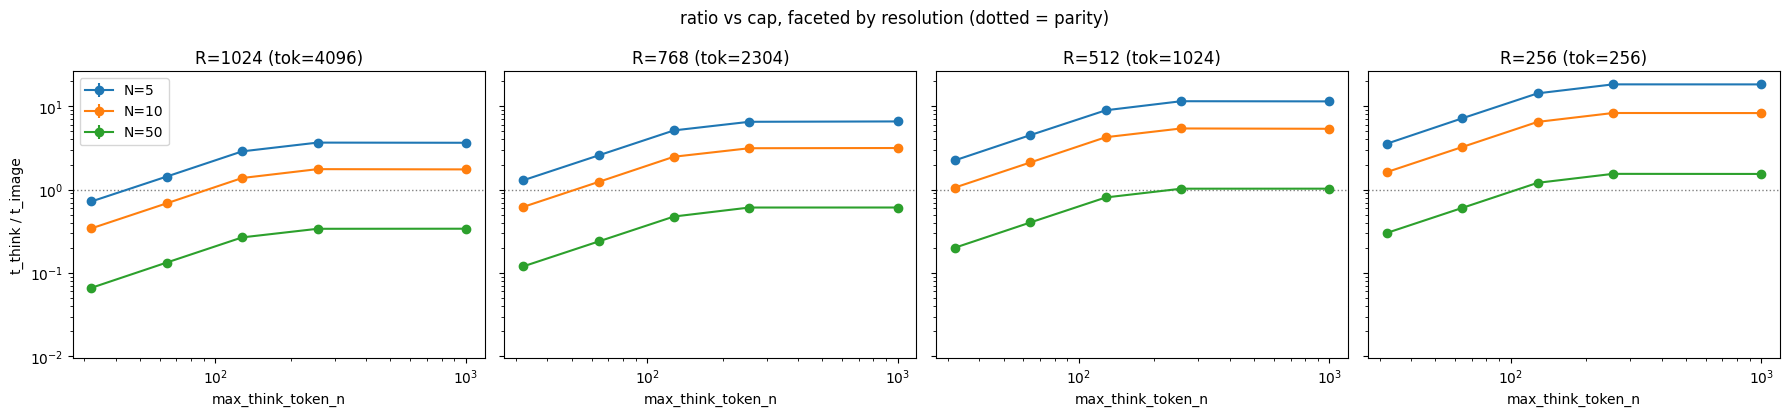

In [7]:
pooled = (
    ok.groupby(["image_side", "num_timesteps", "max_think_token_n"])
    .agg(ratio_mean=("ratio_think_image", "mean"), ratio_std=("ratio_think_image", "std"))
    .reset_index()
)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
for ax, side in zip(axes, sorted(IMAGE_SIDE_LIST, reverse=True)):
    sub_r = pooled[pooled["image_side"] == side]
    for n in sorted(sub_r["num_timesteps"].unique()):
        sub = sub_r[sub_r["num_timesteps"] == n].sort_values("max_think_token_n")
        ax.errorbar(sub["max_think_token_n"], sub["ratio_mean"], yerr=sub["ratio_std"],
                    marker="o", label=f"N={n}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"R={side} (tok={(side // LATENT_DOWNSAMPLE) ** 2})")
    ax.set_xlabel("max_think_token_n")
axes[0].set_ylabel("t_think / t_image"); axes[0].legend()
plt.suptitle("ratio vs cap, faceted by resolution (dotted = parity)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ratio_vs_cap_per_R.png"), dpi=150)
plt.show()


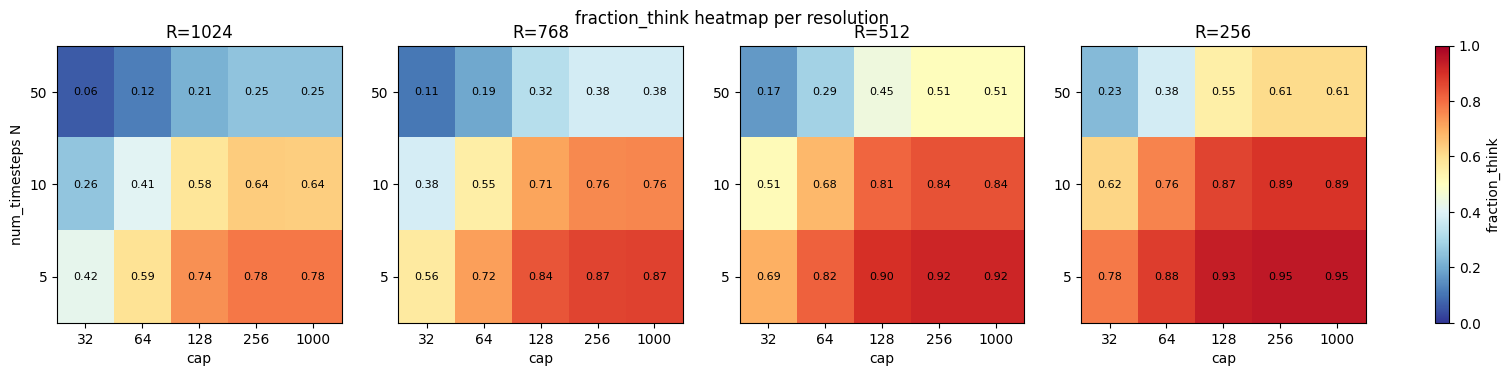

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, side in zip(axes, sorted(IMAGE_SIDE_LIST, reverse=True)):
    sub = ok[ok["image_side"] == side]
    pivot = sub.pivot_table(index="num_timesteps", columns="max_think_token_n",
                            values="fraction_think", aggfunc="mean")
    pivot = pivot.sort_index(ascending=False)
    im = ax.imshow(pivot.values, cmap="RdYlBu_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    ax.set_xlabel("cap"); ax.set_title(f"R={side}")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
axes[0].set_ylabel("num_timesteps N")
fig.colorbar(im, ax=axes, fraction=0.012, label="fraction_think")
plt.suptitle("fraction_think heatmap per resolution")
plt.savefig(os.path.join(OUTPUT_DIR, "fraction_think_heatmap_per_R.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 8. H3(自检):`t_think` 应与分辨率无关

t2i 任务 think 阶段没有任何图像输入,分辨率只在 `gen_image` 才生效。
按 cap 分组做 Kruskal-Wallis(跨 4 个 R),**预期全部不显著**;
若显著,说明计时被污染(如 warm-up 不充分、显存碎片影响)。

In [9]:
print(ok.groupby(["max_think_token_n", "image_side"])["t_think"].mean().unstack().round(3))
print()
for cap in sorted(ok["max_think_token_n"].unique()):
    groups = [ok[(ok["max_think_token_n"] == cap) & (ok["image_side"] == side)]["t_think"].values
              for side in IMAGE_SIDE_LIST]
    stat, p = kruskal(*groups)
    flag = "  ← 异常!检查计时" if p < 0.05 else "(不显著,符合预期)"
    print(f"cap={cap:>5}: Kruskal-Wallis H={stat:.3f}, p={p:.4f} {flag}")


image_side          256    512    768    1024
max_think_token_n                            
32                 1.763  1.763  1.762  1.760
64                 3.522  3.522  3.528  3.521
128                7.060  7.061  7.063  7.068
256                9.028  9.021  9.002  9.015
1000               9.004  9.007  9.015  9.013

cap=   32: Kruskal-Wallis H=1.544, p=0.6722 (不显著,符合预期)
cap=   64: Kruskal-Wallis H=3.482, p=0.3231 (不显著,符合预期)
cap=  128: Kruskal-Wallis H=0.671, p=0.8800 (不显著,符合预期)
cap=  256: Kruskal-Wallis H=0.137, p=0.9870 (不显著,符合预期)
cap= 1000: Kruskal-Wallis H=0.039, p=0.9980 (不显著,符合预期)


## 9. 统计检验:分辨率对 t_image / fraction_think 的效应

配对 Wilcoxon(同一 prompt 在 R=256 vs R=1024 下的均值),每个 N 一组。

In [10]:
R_LOW, R_HIGH = min(IMAGE_SIDE_LIST), max(IMAGE_SIDE_LIST)

for metric in ["t_image", "fraction_think"]:
    print(f"── {metric}: R={R_LOW} vs R={R_HIGH} ──")
    for n in sorted(ok["num_timesteps"].unique()):
        sub = ok[ok["num_timesteps"] == n]
        low = sub[sub["image_side"] == R_LOW].groupby("prompt")[metric].mean()
        high = sub[sub["image_side"] == R_HIGH].groupby("prompt")[metric].mean()
        common = low.index.intersection(high.index)
        if len(common) >= 6:
            stat, p_value = wilcoxon(low.loc[common], high.loc[common])
            print(f"  N={n:>3}: paired prompts={len(common)}, "
                  f"Wilcoxon statistic={stat:.4f}, p={p_value:.6f}")
        else:
            print(f"  N={n:>3}: 配对 prompt 不足({len(common)}),跳过")
    print()


── t_image: R=256 vs R=1024 ──
  N=  5: paired prompts=16, Wilcoxon statistic=0.0000, p=0.000031
  N= 10: paired prompts=16, Wilcoxon statistic=0.0000, p=0.000031
  N= 50: paired prompts=16, Wilcoxon statistic=0.0000, p=0.000031

── fraction_think: R=256 vs R=1024 ──
  N=  5: paired prompts=16, Wilcoxon statistic=0.0000, p=0.000031
  N= 10: paired prompts=16, Wilcoxon statistic=0.0000, p=0.000031
  N= 50: paired prompts=16, Wilcoxon statistic=0.0000, p=0.000031



## 10. 结论与局限性

**结论**(跑完后按拟合结果填写):

1. H1:`t_image = s(R)·N` 在所有分辨率下均成立(§5 各组 R² = ___)
2. H2:`s(R) = a + b·tok` 中 a = ___ s/step(固定开销),b = ___;二次项 c = ___(显著 / 不显著)
3. H3:t_think 与 R 无关(§8 全部 p > 0.05:是 / 否)
4. 推广的比值定律:`ratio ≈ 0.055·T / ((a + b·tok)·N)`;平衡点 `T*(N, R) = s(R)·N / 0.055`

**局限性**:

- BAGEL 训练分辨率为 1024(`max_latent_size=64` 恰好卡在 64×16),**低分辨率下出图质量
  可能明显下降**——本实验只回答延迟问题,质量成本需要单独的评估实验;
- `s(R)` 的标定只有 4 个点,二次项拟合自由度为 1,attention 是否超线性只能定性判断;
  更严格需要非方形 shape 补点(如 512×1024,tok=2048)验证"成本只由 token 总数决定";
- 2-GPU 流水线(PCIe,无 P2P)会给逐 token 解码引入跨卡通信开销,`t_think` 斜率
  (0.055 s/tok)相对单卡系统偏大,但这不影响 R 维度的结论(think 段与 R 无关);
- cap ∈ {32, 64, 128} 为强截断(hit_cap=100%),cap ∈ {256, 1000} 为自然长度(~160 tok),
  与上一实验相同,截断对图像质量的影响不在本实验范围内。
